<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-2/YZ50Hafta2Kod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out

    def __repr__(self):
        return f"Value: {self.data}"

a = Value(5, label='a')
b = Value(3, label='b')
c = a * b
c.label = 'c'
d = Value(2, label='d')
e = Value(-4, label='e')
f = d * e
f.label='f'
g = c + f
g.label='g'
h = Value(-3, label='h')
L = g * h
L.label='L'

{Value: -4, Value: -8, Value: -21, Value: -3, Value: 15, Value: 3, Value: 2, Value: 7, Value: 5}


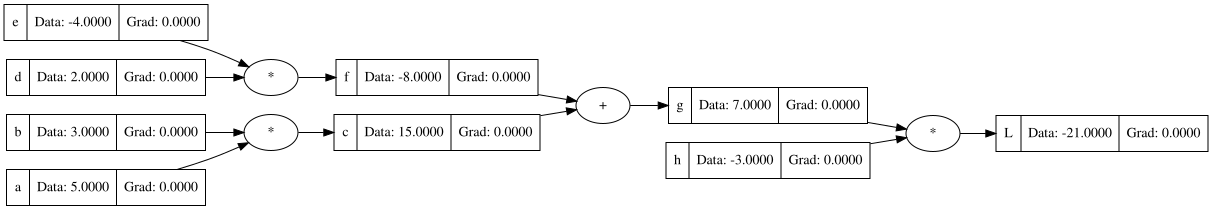

In [111]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v in nodes:
            return
        nodes.add(v)
        for child in v._prev:
            edges.add((v, child))
            build(child)

    build(root)

    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    print(nodes)
    for node in nodes:
        dot.node(name=str(id(node)), label="{%s | Data: %.4f | Grad: %.4f}" % (node.label, node.data, node.grad), shape='record')

        if node._op != '':
            dot.node(name=str(id(node))+'op', label=node._op)
            dot.edge(str(id(node))+'op', str(id(node)))

    for edge in edges:
        dot.edge(str(id(edge[1])), str(id(edge[0]))+'op')

    return dot

draw_dot(L)

In [112]:
# Global turev = lokal turev * zincir kurali carpani

L.grad = 1.0

h.grad = g.data * L.grad
g.grad = h.data * L.grad

f.grad = 1.0 * g.grad
c.grad = 1.0 * g.grad

e.grad = d.data * f.grad
d.grad = e.data * f.grad

b.grad = a.data * c.grad
a.grad = b.data * c.grad

{Value: -4, Value: -8, Value: -21, Value: -3, Value: 15, Value: 3, Value: 2, Value: 7, Value: 5}


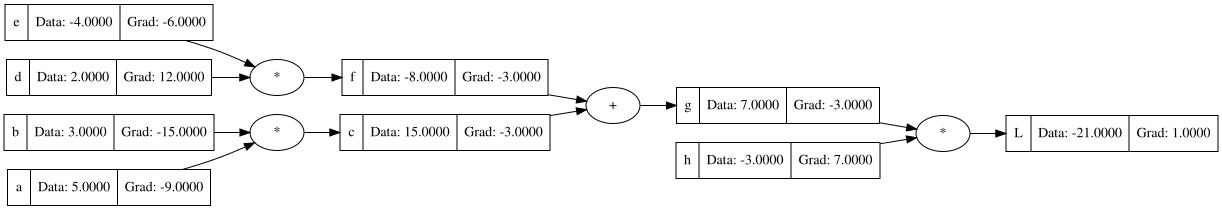

In [113]:
draw_dot(L)

In [114]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out

    def tanh(self):
        num = math.exp(2 * self.data) - 1
        den = num + 2
        out = Value(num / den, _children=(self,), _op='tanh')
        return out

    def __repr__(self):
        return f"Value: {self.data}"

{Value: -1.4, Value: 0.42189900525000773, Value: 1.5, Value: -1.0500000000000003, Value: 2.5, Value: 3.5, Value: 0.44999999999999973, Value: 2.4499999999999997, Value: -3.5, Value: 0.7}


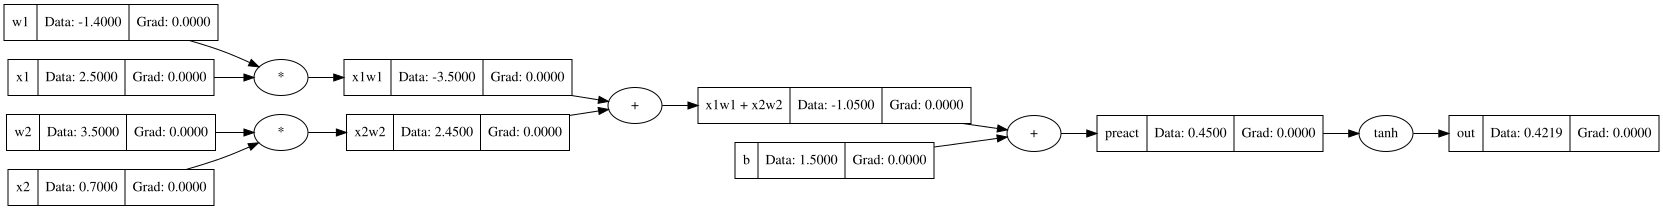

In [115]:
x1 = Value(2.5, label='x1')
x2 = Value(0.7, label='x2')

w1 = Value(-1.4, label='w1')
w2 = Value(3.5, label='w2')

b = Value(1.5, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'

preact = x1w1x2w2 + b
preact.label = 'preact'

output = preact.tanh()
output.label = 'out'

draw_dot(output)

In [116]:
output.grad = 1.0
preact.grad = (1 - output.data**2) * output.grad

x1w1x2w2.grad = 1.0 * preact.grad
b.grad = 1.0 * preact.grad

x1w1.grad = 1.0 * x1w1x2w2.grad
x2w2.grad = 1.0 * x1w1x2w2.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

{Value: -1.4, Value: 0.42189900525000773, Value: 1.5, Value: -1.0500000000000003, Value: 2.5, Value: 3.5, Value: 0.44999999999999973, Value: 2.4499999999999997, Value: -3.5, Value: 0.7}


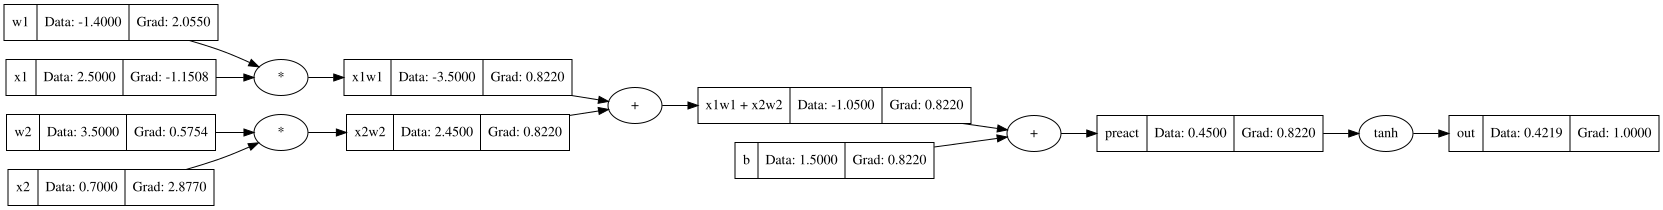

In [117]:
draw_dot(output)